# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
print('Everything is imported ')

Everything is imported 


# **Data Exploration**

## **Load the Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 4540 Rows and 7 columns with 40 Duplicates


In [4]:
df.sample(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
3428,57.6,16.5,215.6,4836.0,2.0,1.0,1
4051,32.6,18.9,205.1,4827.0,0.0,0.0,0
3969,38.8,NaN,201.9,5840.0,1.0,1.0,1
247,52.6,15.2,210.9,2910.0,0.0,0.0,1
875,47.0,16.5,176.6,3880.0,1.0,0.0,0
1502,45.1,20.7,215.0,4222.0,0.0,0.0,0
4141,NaN,21.8,200.6,4884.0,NaN,0.0,1
2878,45.8,19.6,170.6,3932.0,0.0,1.0,0
544,50.0,14.6,214.0,4191.0,2.0,0.0,1
4487,56.7,14.2,225.2,4387.0,0.0,1.0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     4451 non-null   str    
 1   bill_depth_mm      4450 non-null   float64
 2   flipper_length_mm  4449 non-null   float64
 3   body_mass_g        4450 non-null   float64
 4   island             4450 non-null   float64
 5   sex                4449 non-null   float64
 6   species            4540 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 266.4 KB


In [6]:
df.describe()

,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
count,4450.000000,4449.000000,4450.000000,4450.000000,4449.000000,4540.000000
mean,17.479438,202.255923,4518.510787,1.006966,0.495167,0.507930
std,2.663486,19.095726,1768.947293,0.815503,0.500033,0.499992
min,-3.000000,170.000000,-100.000000,0.000000,0.000000,0.000000
25%,15.200000,186.100000,3591.000000,0.000000,0.000000,0.000000
50%,17.400000,201.900000,4480.500000,1.000000,0.000000,1.000000
75%,19.700000,218.200000,5392.000000,2.000000,1.000000,1.000000
max,50.000000,500.000000,99999.000000,2.000000,1.000000,1.000000


In [7]:
df.isna().sum()

bill_length_mm       89
bill_depth_mm        90
flipper_length_mm    91
body_mass_g          90
island               90
sex                  91
species               0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy created')

Copy created


## **DataType**

In [10]:
df_copy['bill_length_mm'] = df_copy['bill_length_mm'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [12]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [14]:
Columns = df_copy.columns.tolist()
Columns.remove('species')
Columns.remove('sex')
Columns.remove('island')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [16]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 40
After: 0


In [18]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('species')
Round.remove('sex')
Round.remove('island')

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['sex','island']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
bill_length_mm       90
bill_depth_mm        92
flipper_length_mm    91
body_mass_g          92
island               90
sex                  90
species               0
dtype: int64
NaN values in the Dataset After Cleaning is: 
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
island               0
sex                  0
species              0
dtype: int64


# **Data Preperation**

In [19]:
features = df_copy.columns.tolist()
features.remove('species')
X = df_copy[features]
y = df_copy['species']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (4500, 6)
y Shape: (4500,)


In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (3600, 6)
X_test Shape:  (900, 6)
y_train Shape: (3600,)
y_test Shape:  (900,)


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Suggested starting K: {int(math.sqrt(len(X_train)))}")

Suggested starting K: 60


# **Model**

## **Optimal K**

In [22]:
train_scores = []
test_scores  = []
k_range      = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(test_scores)]
print(f"Optimal K: {best_k}")

Optimal K: 13


## **Train**

In [23]:
model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',   # distance metric
    weights='uniform'     # all neighbors vote equally
)

model.fit(X_train_scaled, y_train)
print(f"Model trained with K={best_k} ✅")

Model trained with K=13 ✅


## **Evaluation & Pridict**

In [24]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.77      0.80      0.78       432
         1.0       0.81      0.78      0.79       468

    accuracy                           0.79       900
   macro avg       0.79      0.79      0.79       900
weighted avg       0.79      0.79      0.79       900

Accuracy: 0.7889


## **OverFitting Check**

In [25]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.7994
Testing Accuracy:  0.7889
Gap:               0.0106


## **Charts**

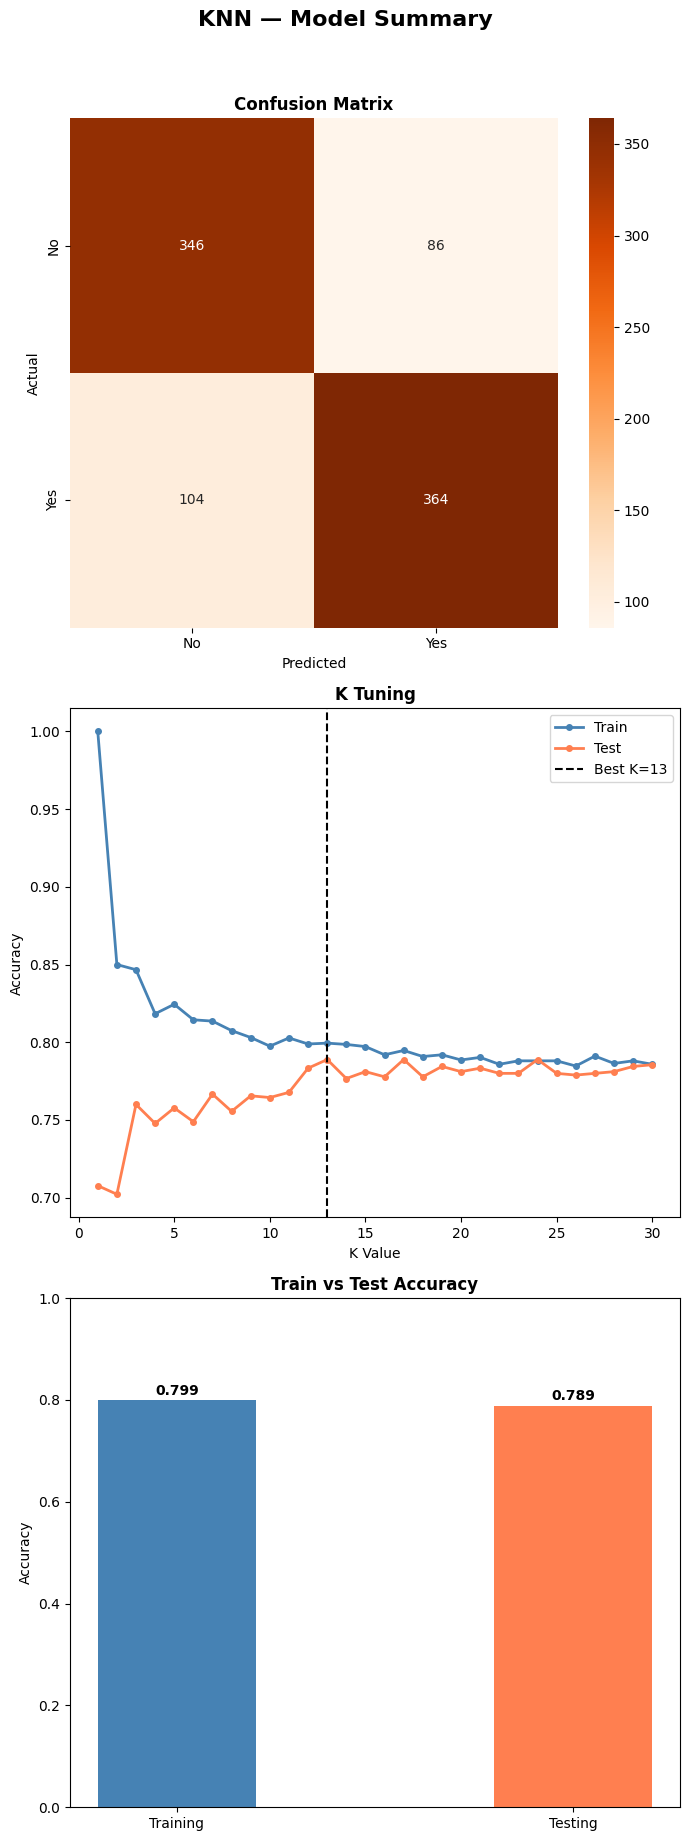

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — K Tuning
axes[1].plot(k_range, train_scores, marker='o', markersize=4,
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(k_range, test_scores,  marker='o', markersize=4,
             label='Test',  color='coral',     linewidth=2)
axes[1].axvline(best_k, linestyle='--', color='black',
                label=f'Best K={best_k}')
axes[1].set_title('K Tuning', fontweight='bold')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('KNN — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()